# Instant Policy - PoC
The aim of this notebook is to perform a "simple" proof of concept for the Instant Policy approach. The model will be trained with multiple simple planar trajectories and then evaluated against other simples and complex trajectories.

In [1]:
from src.trajectory_generator import TrajectoryGenerator
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def perturb_params(params: dict, noise_scale: float = 0.15) -> dict:
    """Perturba levemente los parámetros para generar una demo semánticamente consistente."""
    perturbed = {}
    for key, value in params.items():
        if isinstance(value, (int, float)):
            # Perturbación relativa: ±15% del valor original
            perturbed[key] = value * (1 + np.random.uniform(-noise_scale, noise_scale))
        elif isinstance(value, tuple):
            # Para tuplas (ej: start=(x, y))
            perturbed[key] = tuple(
                v * (1 + np.random.uniform(-noise_scale, noise_scale)) for v in value
            )
        else:
            perturbed[key] = value
    return perturbed
    
def create_demo_pair(generator_fn, params: dict, n_points: int):
    """
    Crea el par (context, target) para In-Context Imitation Learning.
    
    - target:  trayectoria "objetivo" generada con los params originales
    - context: trayectoria semánticamente similar pero geométricamente distinta,
               generada con params levemente perturbados (es la "demo experta")
    """
    target  = generator_fn(n_points=n_points, **params).astype(np.float32)
    context = generator_fn(n_points=n_points, **perturb_params(params)).astype(np.float32)
    return context, target

In [3]:
def get_trajectory_types(n_points):
    """Devuelve la lista de generadores aleatorios parametrizados"""
    return [
        ("linear", TrajectoryGenerator.linear, dict( 
            start=(np.random.uniform(-1, 1), np.random.uniform(-1, 1)), 
            angle=np.random.uniform(0, 360), 
            length=np.random.uniform(0.5, 2.0)
        )),
        ("sinusoidal", TrajectoryGenerator.sinusoidal, dict( 
            amp=np.random.uniform(0.1, 1.0), 
            freq=np.random.uniform(0.5, 3.0), 
            phase=np.random.uniform(0, 2 * np.pi)
        )),
        ("circular", TrajectoryGenerator.circular, dict( 
            radius=np.random.uniform(0.5, 2.0), 
            arc_ratio=np.random.uniform(0.5, 1.0), 
            start_angle=np.random.uniform(0, 360)
        )),
        ("parabolic", TrajectoryGenerator.parabolic, dict( 
            a=np.random.uniform(-2.0, 2.0), 
            h=np.random.uniform(-1.0, 1.0), 
            k=np.random.uniform(-1.0, 1.0)
        )),
        ("exponential", TrajectoryGenerator.exponential, dict( 
            a=np.random.uniform(0.5, 2.0), 
            b=np.random.uniform(-1.5, 1.5)
        )),
        ("sigmoid", TrajectoryGenerator.sigmoid, dict( 
            L=np.random.uniform(0.5, 2.0), 
            k=np.random.uniform(5, 15), 
            x0=np.random.uniform(0.5, 1.5)
        )),
        ("staggered_step", TrajectoryGenerator.staggered_step, dict(
            n_steps=np.random.randint(2, 6), 
            step_height=np.random.uniform(0.2, 1.0)
        )),
        ("spiral", TrajectoryGenerator.spiral, dict( 
            b=np.random.uniform(0.05, 0.2), 
            theta_max=np.random.uniform(2 * np.pi, 6 * np.pi)
        )),
        ("lemniscate", TrajectoryGenerator.lemniscate, dict(
            a=np.random.uniform(1.0, 2.5))),
        ("lissajous", TrajectoryGenerator.lissajous, dict(
            A=np.random.uniform(0.5, 2.0), 
            B=np.random.uniform(0.5, 2.0), 
            a=np.random.randint(1, 5), 
            b=np.random.randint(1, 5), 
            delta=np.random.uniform(0, np.pi)
        ))
    ]

In [4]:
def normalize_to_minus1_plus1(trajectories: list[np.ndarray]) -> tuple[list[np.ndarray], dict]:
    """
    Normaliza un conjunto de trayectorias al rango [-1, 1] usando stats globales.
    Retorna las trayectorias normalizadas y los parámetros para desnormalizar.
    """
    all_points = np.concatenate(trajectories, axis=0)  # shape: (N_total, 2)
    
    xy_min = all_points.min(axis=0)  # [x_min, y_min]
    xy_max = all_points.max(axis=0)  # [x_max, y_max]
    xy_range = xy_max - xy_min
    
    # Evitar división por cero
    xy_range = np.where(xy_range == 0, 1.0, xy_range)
    
    norm_stats = {"min": xy_min, "max": xy_max, "range": xy_range}
    
    normalized = [
        2.0 * (traj - xy_min) / xy_range - 1.0
        for traj in trajectories
    ]
    return normalized, norm_stats
def compute_relative_coords(context: np.ndarray, target: np.ndarray) -> np.ndarray:
    """
    Representa cada waypoint del target como desplazamiento relativo
    respecto a su nodo más cercano en el context.
    
    Retorna target_rel: shape (n_points, 2) — coordenadas relativas.
    """
    target_rel = np.zeros_like(target)
    for i, t_point in enumerate(target):
        # Distancia al punto más cercano del contexto
        dists = np.linalg.norm(context - t_point, axis=1)
        nearest_idx = np.argmin(dists)
        target_rel[i] = t_point - context[nearest_idx]
    return target_rel

In [5]:
def orchestrator(file_name, n_per_type=100, n_points=100):
    """Orquestador principal para generar y guardar el dataset."""
    
    with h5py.File(file_name, 'w') as f:
        data_group = f.create_group("data")
        demo_idx = 0
        
        all_contexts = []
        all_targets  = []
        all_names    = []
        
        for _ in range(n_per_type):
            for name, fn, params in get_trajectory_types(n_points):
                ctx, tgt = create_demo_pair(fn, params, n_points)
                all_contexts.append(ctx)
                all_targets.append(tgt)
                all_names.append(name)
        
        # Paso 1: Normalización global a [-1, 1]
        all_traj_combined = all_contexts + all_targets
        all_traj_norm, norm_stats = normalize_to_minus1_plus1(all_traj_combined)
        n = len(all_contexts)
        contexts_norm = all_traj_norm[:n]
        targets_norm  = all_traj_norm[n:]
        
        # Paso 2: Guardar cada demo en HDF5 con el índice correcto
        for i in range(n):
            demo_grp = data_group.create_group(f"demo_{demo_idx}")
            demo_grp.create_dataset("context", data=contexts_norm[i])
            demo_grp.create_dataset("target",  data=targets_norm[i])
            
            # Metadatos para facilitar el filtrado posterior
            demo_grp.attrs["type"]        = all_names[i]
            demo_grp.attrs["num_samples"] = n_points
            
            demo_idx += 1
        
        # Atributo global del dataset
        f.attrs["total_demos"] = demo_idx

    print(f"\n¡Éxito! Dataset guardado en '{file_name}' con {demo_idx} demostraciones totales.")
    print(f"Rango X global: [{norm_stats['min'][0]:.3f}, {norm_stats['max'][0]:.3f}]")
    print(f"Rango Y global: [{norm_stats['min'][1]:.3f}, {norm_stats['max'][1]:.3f}]")


In [8]:
FILENAME = "dataset_instant_policy_2d.h5"
N_EXAMPLES = 100
N_POINTS   = 50
orchestrator(FILENAME, n_per_type=N_EXAMPLES, n_points=N_POINTS)


¡Éxito! Dataset guardado en 'dataset_instant_policy_2d.h5' con 1000 demostraciones totales.
Rango X global: [-3.220, 3.487]
Rango Y global: [-7.424, 38.591]


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_9880\2859700421.py:4: DeprecationWarning: This function is deprecated. Please call randint(0, 1000 + 1) instead
  d = f[f'data/demo_{np.random.random_integers(0, n)}'] # Una demo aleatoria (probablemente sinusoidal)


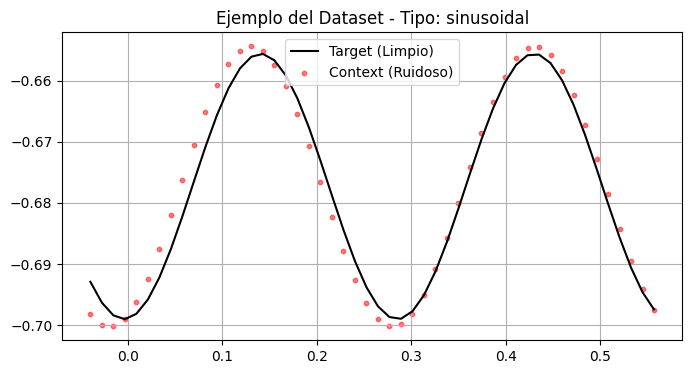

In [14]:
# Prueba rápida de visualización
with h5py.File(FILENAME, 'r') as f:
    n = f.attrs['total_demos']
    d = f[f'data/demo_{np.random.random_integers(0, n)}'] # Una demo aleatoria (probablemente sinusoidal)
    plt.figure(figsize=(8,4))
    plt.plot(d['target'][:,0], d['target'][:,1], 'k-', label='Target (Limpio)')
    plt.scatter(d['context'][:,0], d['context'][:,1], c='r', alpha=0.5, s=10, label='Context (Ruidoso)')
    plt.title(f"Ejemplo del Dataset - Tipo: {d.attrs['type']}")
    plt.legend()
    plt.grid(True)
    plt.show()